# SILVA Implicit DAE and Adversarial Residual Lab

This lab derives an implicit Runge-Kutta layer for index-1
differential-algebraic equations, validates one- and two-stage roots, and then
adds an optional adversarial residual objective. DAE-PINNs motivate the
implicit stage construction [52]. The similarly named DEQGAN uses “DEQ” to
mean “Differential Equation,” not “Deep Equilibrium” [53].

<!-- silva-numbered-citations:start -->
**Numbered literature:** [1](https://jseluis.github.io/silva-networks/paper/references/#ref-1), [52](https://jseluis.github.io/silva-networks/paper/references/#ref-52), [53](https://jseluis.github.io/silva-networks/paper/references/#ref-53). Each number opens the complete citation and its primary external source.
<!-- silva-numbered-citations:end -->


In [1]:
from pathlib import Path
import importlib.util
import subprocess
import sys

REPO_URL = "https://github.com/jseluis/silva-networks.git"

def find_local_silva_root():
    candidates = [Path.cwd(), Path("/content/silva-networks")]
    root = Path.cwd()
    while root != root.parent:
        candidates.append(root)
        root = root.parent
    for candidate in candidates:
        if (candidate / "src" / "silva_networks").exists():
            return candidate
    return None

root = find_local_silva_root()
if root is not None:
    sys.path.insert(0, str(root / "src"))
elif importlib.util.find_spec("silva_networks") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", f"git+{REPO_URL}"])
    root = Path.cwd()
else:
    root = Path.cwd()

In [2]:
import torch
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})

from silva_networks import (
    SILVAImplicitDAEStep,
    SILVAResidualDiscriminator,
    make_linear_dae_dataset,
    silva_adversarial_residual_loss,
)

torch.manual_seed(250)

## 1. Semi-Explicit Index-1 DAE

Separate differential and algebraic states:

$$
\dot y=f(y,z),
\qquad 0=g(y,z).
$$

The teaching system is

$$
\dot y=-y+z,
\qquad g(y,z)=z-\frac12y.
$$

Eliminating $z$ gives $\dot y=-y/2$, so
$y(t)=y_0e^{-t/2}$ and $z(t)=y(t)/2$.

In [3]:
data = make_linear_dae_dataset(steps=8, dimensions=1, step_size=0.1)
assert data.constraint_residual().abs().max() == 0
print("trajectory:", tuple(data.differential.shape))
print("exact final differential state:", float(data.differential[-1]))

trajectory: (9, 1)
exact final differential state: 0.3351600170135498


## 2. Implicit Runge-Kutta Stage Equations

For $s$ stages and Butcher coefficients $(A,b,c)$,

$$
Y_j=y_n+h\sum_{i=1}^s a_{ji}f(Y_i,Z_i),
\qquad g(Y_j,Z_j)=0,
$$

$$
y_{n+1}=y_n+h\sum_{i=1}^s b_i f(Y_i,Z_i),
\qquad g(y_{n+1},z_{n+1})=0.
$$

All stage and endpoint algebraic variables form one root vector. A damped
Newton solve makes this root system an implicit SILVA layer. The dynamics may
be known, learned, or a composition of both.

## 3. Backward Euler Is the One-Stage Case

With $A=[1]$, $b=[1]$, and $c=[1]$,

$$
y_{n+1}=y_n+h(-y_{n+1}+z_{n+1}),
\qquad z_{n+1}=\frac12y_{n+1}.
$$

Therefore

$$
y_{n+1}=\frac{y_n}{1+h/2}.
$$

In [4]:
backward_euler = SILVAImplicitDAEStep(max_iter=6, tol=1e-8)
step = backward_euler(
    data.differential[:1],
    data.algebraic[:1],
    data.step_size,
    data.dynamics,
    data.constraint,
)
discrete_exact = data.differential[:1] / (1.0 + data.step_size / 2.0)
assert step.residual < 1e-7
assert torch.allclose(step.differential, discrete_exact, atol=1e-6)
print("root residual:", step.residual)
print("differential/algebraic:", float(step.differential), float(step.algebraic))

root residual: 1.862645149230957e-09
differential/algebraic: 0.4761904776096344 0.2380952388048172


## 4. Two-Stage Gauss-Legendre Layer

The fourth-order two-stage tableau is

$$
A=\begin{bmatrix}
1/4 & 1/4-\sqrt3/6\\
1/4+\sqrt3/6 & 1/4
\end{bmatrix},
\quad
b=\begin{bmatrix}1/2&1/2\end{bmatrix}.
$$

Changing the tableau changes the discretization while preserving the public
DAE root contract.

In [5]:
root_three = 3.0**0.5
gauss = SILVAImplicitDAEStep(
    a=torch.tensor([[0.25, 0.25-root_three/6], [0.25+root_three/6, 0.25]]),
    b=torch.tensor([0.5, 0.5]),
    c=torch.tensor([0.5-root_three/6, 0.5+root_three/6]),
    max_iter=6,
    tol=1e-8,
)
gauss_step = gauss(
    data.differential[:1], data.algebraic[:1], data.step_size,
    data.dynamics, data.constraint,
)
assert gauss_step.stage_differential.shape == (1, 2, 1)
assert gauss_step.residual < 1e-6
print("two-stage result:", float(gauss_step.differential))

two-stage result: 0.4756147265434265


## 5. Roll Out the Implicit Layer

Each step solves a local root. A trajectory is a sequence of such implicit
points; it is not one globally weight-tied deep-equilibrium state. This
classification keeps DAE time stepping distinct from a Bai-style DEQ while
still placing the implicit layer inside SILVA.

In [6]:
y = data.differential[:1]
z = data.algebraic[:1]
trajectory = [y.detach().squeeze()]
root_residuals = []
for _ in range(8):
    result = gauss(y, z, data.step_size, data.dynamics, data.constraint)
    y, z = result.differential, result.algebraic
    trajectory.append(y.detach().squeeze())
    root_residuals.append(result.residual)
trajectory = torch.stack(trajectory)
print("maximum rollout root residual:", max(root_residuals))

maximum rollout root residual: 1.890951750738168e-08


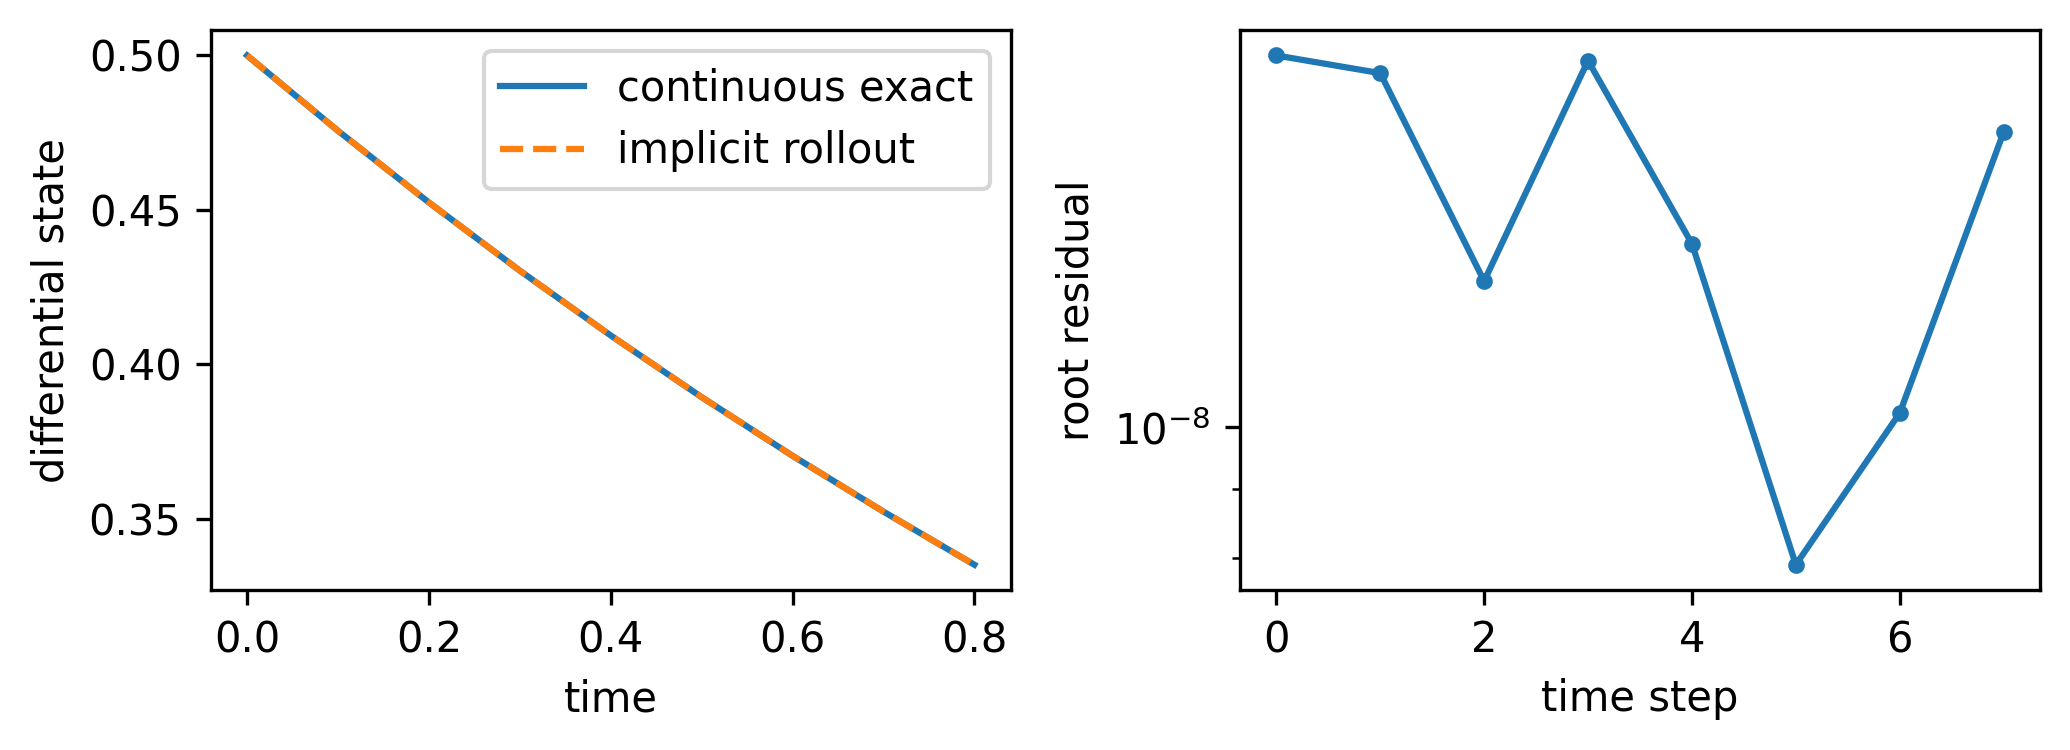

In [7]:
figure, axes = plt.subplots(1, 2, figsize=(7.0, 2.6))
axes[0].plot(data.times[:, 0], data.differential[:, 0], label="continuous exact")
axes[0].plot(data.times[:, 0], trajectory, "--", label="implicit rollout")
axes[0].set(xlabel="time", ylabel="differential state")
axes[0].legend()
axes[1].semilogy(root_residuals, marker="o", markersize=3)
axes[1].set(xlabel="time step", ylabel="root residual")
figure.tight_layout()
plt.show()

## 6. Adversarial Residual Objective and Naming Boundary

An optional discriminator can compare equation residuals $r_\theta$ with a
near-zero reference distribution $r_0$. With discriminator $D_\omega$,

$$
\mathcal L_D
=-\mathbb E\log D_\omega(r_0)
-\mathbb E\log(1-D_\omega(r_\theta)),
$$

$$
\mathcal L_G=-\mathbb E\log D_\omega(r_\theta).
$$

This objective follows the differential-equation GAN work [53]. It is not an
equilibrium solver and is deliberately exposed as
`silva_adversarial_residual_loss`, not as a selectable DEQ family.

In [8]:
discriminator = SILVAResidualDiscriminator(residual_dim=1, hidden_dim=8, depth=1)
equation_residual = data.constraint(data.differential, data.algebraic)
equation_residual = equation_residual + 0.02 * torch.randn_like(equation_residual)
losses = silva_adversarial_residual_loss(
    discriminator,
    equation_residual,
    reference=torch.zeros_like(equation_residual),
    instance_noise=0.005,
)
assert torch.isfinite(losses.generator + losses.discriminator)
print("generator/discriminator:", float(losses.generator), float(losses.discriminator))

generator/discriminator: 0.6628165245056152 1.3866183757781982


## 7. Choosing the Physics Construction

Use a physics-informed equilibrium when the solution representation itself is
a fixed point and implicit time derivatives are needed. Use an implicit DAE
step when every time advance must satisfy differential and algebraic stage
equations. Add adversarial residual matching only when distributional residual
training is part of the study; it supplements rather than replaces direct
constraint, root, and trajectory diagnostics.

## Where to Go Next

| Question | Page |
| --- | --- |
| How are the DAE stage roots derived? | [Physics-Informed Equilibria](https://jseluis.github.io/silva-networks/learn/physics-informed-equilibria/#differential-algebraic-equations) |
| Why is the residual objective not a DEQ family? | [Adversarial Residual Objective](https://jseluis.github.io/silva-networks/learn/physics-informed-equilibria/#adversarial-equation-residual-objective) |
| Which DAE and residual objects are public? | [Physics-Informed API](https://jseluis.github.io/silva-networks/api/physics_informed/) |
